# Type Ia 超新星似然

本教程演示 HIcosmo 的超新星似然函数。

**关键 API**：
- `SN_likelihood(model, dataset)` — 创建超新星似然
- `available_sn_datasets()` — 列出可用数据集
- `M_B='marginalize'|'free'|float` — M_B 处理方式
- `hicosmo('LCDM', 'sn', ...)` — 极简推断 API

In [1]:
import hicosmo as hc
hc.init()

INFO:hicosmo.samplers.init:Configured 8 JAX devices × 1 threads (parallel mode)
INFO:hicosmo.samplers.init:✅ HIcosmo: 8 devices ready for parallel MCMC


True

## 1. 可用数据集

In [2]:
from hicosmo.likelihoods import available_sn_datasets

print("可用超新星数据集:", available_sn_datasets())

可用超新星数据集: ['pantheon+', 'pantheon+shoes']


## 2. 创建似然函数

$$\chi^2 = \Delta\mu^T \cdot C^{-1} \cdot \Delta\mu$$

In [3]:
from hicosmo.likelihoods import SN_likelihood
from hicosmo.models import LCDM

# 创建 Pantheon+ 似然
sne = SN_likelihood(LCDM, "pantheon+")

print(f"数据点: {sne.n_sne}")
print(f"红移范围: [{min(sne.z_cmb):.3f}, {max(sne.z_cmb):.3f}]")

数据点: 1580
红移范围: [0.010, 2.261]


In [4]:
# 计算似然值
print(f"log L(H0=70, Ωm=0.3) = {sne(H0=70, Omega_m=0.3):.2f}")
print(f"log L(Planck)        = {sne(H0=67.36, Omega_m=0.3153):.2f}")

log L(H0=70, Ωm=0.3) = -694.86
log L(Planck)        = -693.65


## 3. M_B 处理方式

绝对星等 $M_B$ 有三种处理方式：

In [5]:
# 方式1: 解析边缘化（默认，推荐）
sne_marg = SN_likelihood(LCDM, "pantheon+", M_B="marginalize")
print(f"边缘化: nuisance = {[p.name for p in sne_marg.nuisance_parameters]}")

# 方式2: M_B 作为自由参数
sne_free = SN_likelihood(LCDM, "pantheon+", M_B="free")
print(f"自由:   nuisance = {[p.name for p in sne_free.nuisance_parameters]}")

# 方式3: 固定 M_B 值
sne_fixed = SN_likelihood(LCDM, "pantheon+", M_B=-19.3)
print(f"固定:   nuisance = {[p.name for p in sne_fixed.nuisance_parameters]}")

边缘化: nuisance = []
自由:   nuisance = ['M_B']
固定:   nuisance = []


In [6]:
# 三种方式的似然值比较
print(f"边缘化:    log L = {sne_marg(H0=70, Omega_m=0.3):.2f}")
print(f"M_B=-19.3: log L = {sne_fixed(H0=70, Omega_m=0.3):.2f}")
print(f"M_B 自由:  log L = {sne_free(H0=70, Omega_m=0.3, M_B=-19.3):.2f}")

边缘化:    log L = -694.86
M_B=-19.3: log L = -829.73
M_B 自由:  log L = -829.73


## 4. Pantheon+SH0ES（Hubble Tension）

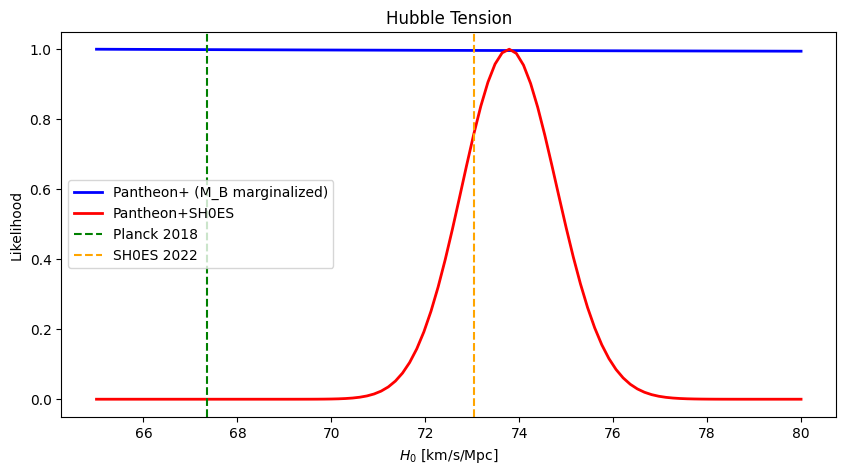

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 含 Cepheid 校准
sne_shoes = SN_likelihood(LCDM, "pantheon+shoes")

# 比较两个数据集
H0_grid = np.linspace(65, 80, 100)
log_L1 = np.array([sne(H0=H0, Omega_m=0.3) for H0 in H0_grid])
log_L2 = np.array([sne_shoes(H0=H0, Omega_m=0.3) for H0 in H0_grid])

plt.figure(figsize=(10, 5))
plt.plot(H0_grid, np.exp(log_L1 - log_L1.max()), 'b-', lw=2, label='Pantheon+ (M_B marginalized)')
plt.plot(H0_grid, np.exp(log_L2 - log_L2.max()), 'r-', lw=2, label='Pantheon+SH0ES')
plt.axvline(67.36, c='green', ls='--', label='Planck 2018')
plt.axvline(73.04, c='orange', ls='--', label='SH0ES 2022')
plt.xlabel(r'$H_0$ [km/s/Mpc]'); plt.ylabel('Likelihood')
plt.title('Hubble Tension'); plt.legend()
plt.savefig('figures/03_hubble_tension.pdf', dpi=150, bbox_inches='tight')
plt.show()

## 5. 似然面可视化

/var/folders/cb/pd_82c9j2s5gbwt3zd7_shkr0000gn/T/ipykernel_59507/1549859745.py:13: UserWarning: Glyph 32422 (\N{CJK UNIFIED IDEOGRAPH-7EA6}) missing from current font.
  plt.savefig('figures/03_sn_likelihood_surface.pdf', dpi=150, bbox_inches='tight')
/var/folders/cb/pd_82c9j2s5gbwt3zd7_shkr0000gn/T/ipykernel_59507/1549859745.py:13: UserWarning: Glyph 26463 (\N{CJK UNIFIED IDEOGRAPH-675F}) missing from current font.
  plt.savefig('figures/03_sn_likelihood_surface.pdf', dpi=150, bbox_inches='tight')
/var/folders/cb/pd_82c9j2s5gbwt3zd7_shkr0000gn/T/ipykernel_59507/1549859745.py:13: UserWarning: Glyph 32422 (\N{CJK UNIFIED IDEOGRAPH-7EA6}) missing from current font.
  plt.savefig('figures/03_sn_likelihood_surface.pdf', dpi=150, bbox_inches='tight')
/var/folders/cb/pd_82c9j2s5gbwt3zd7_shkr0000gn/T/ipykernel_59507/1549859745.py:13: UserWarning: Glyph 26463 (\N{CJK UNIFIED IDEOGRAPH-675F}) missing from current font.
  plt.savefig('figures/03_sn_likelihood_surface.pdf', dpi=150, bbox_inches='

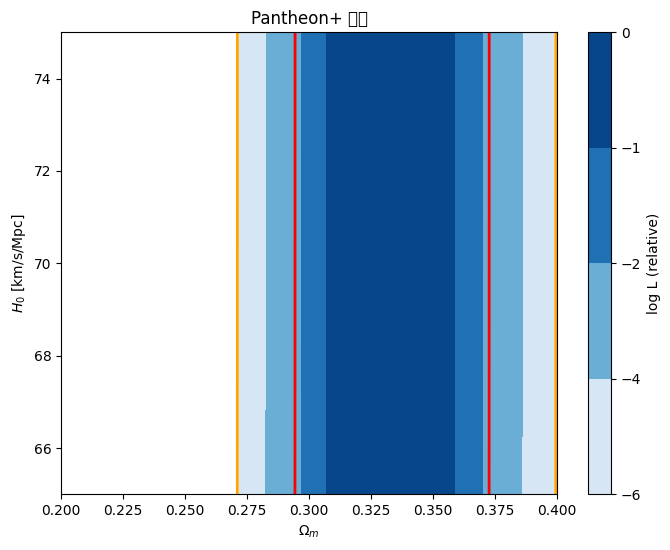

In [8]:
# H0-Omega_m 似然面
H0_grid = np.linspace(65, 75, 50)
Om_grid = np.linspace(0.2, 0.4, 50)
log_L = np.array([[sne(H0=H0, Omega_m=Om) for Om in Om_grid] for H0 in H0_grid])
log_L -= log_L.max()

plt.figure(figsize=(8, 6))
plt.contourf(Om_grid, H0_grid, log_L, levels=[-6, -4, -2, -1, 0], cmap='Blues')
plt.colorbar(label='log L (relative)')
plt.contour(Om_grid, H0_grid, log_L, levels=[-6.18, -2.3], colors=['orange', 'red'], linewidths=2)
plt.xlabel(r'$\Omega_m$'); plt.ylabel(r'$H_0$ [km/s/Mpc]')
plt.title('Pantheon+ 约束')
plt.savefig('figures/03_sn_likelihood_surface.pdf', dpi=150, bbox_inches='tight')
plt.show()

## 6. Hubble 图

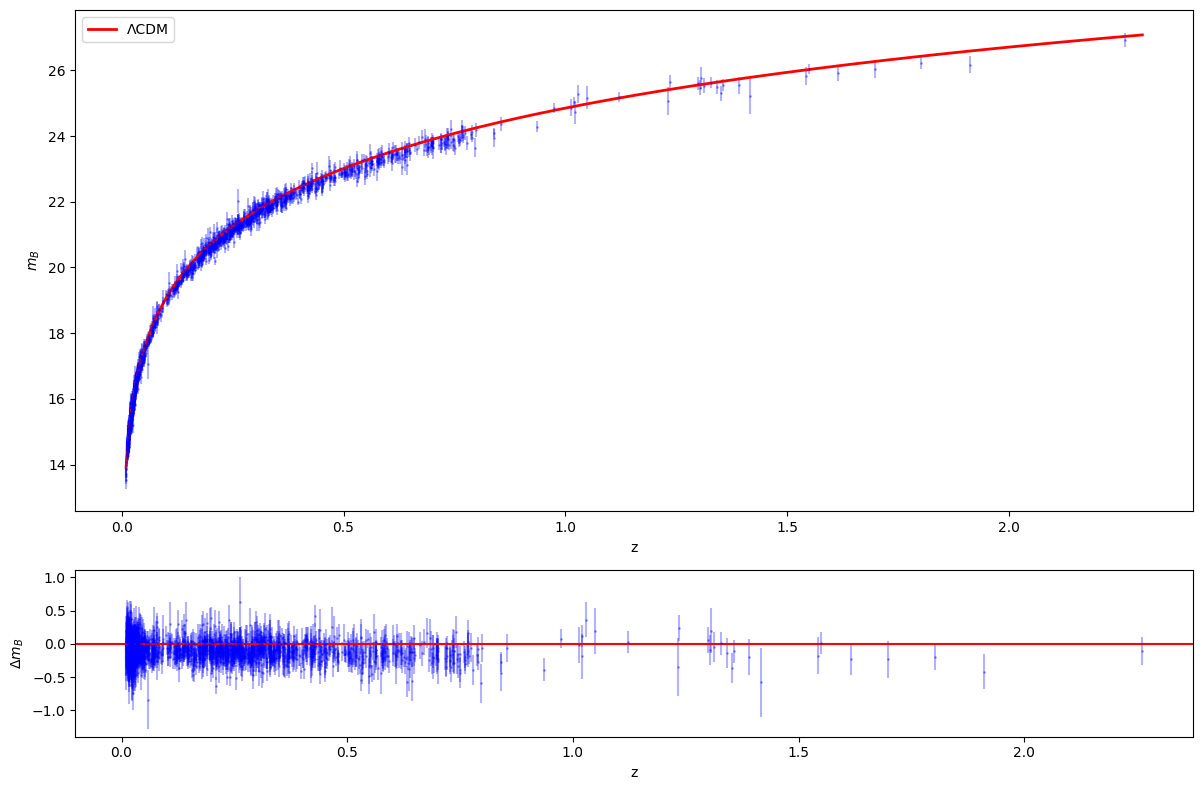

In [9]:
from hicosmo.likelihoods import PantheonPlusLikelihood

data = PantheonPlusLikelihood()
lcdm = LCDM(H0=70, Omega_m=0.3)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})

# Hubble 图
z_data, mb_data = np.array(data.z_cmb), np.array(data.m_obs)
mb_err = np.sqrt(np.diag(data.covariance))
z_th = np.linspace(0.01, 2.3, 200)
mu_th = [lcdm.distance_modulus(zi) for zi in z_th]

axes[0].errorbar(z_data, mb_data, yerr=mb_err, fmt='.', alpha=0.3, c='blue', markersize=2)
axes[0].plot(z_th, np.array(mu_th) - 19.25, 'r-', lw=2, label='ΛCDM')
axes[0].set_xlabel('z'); axes[0].set_ylabel(r'$m_B$'); axes[0].legend()

# 残差
mu_data = [lcdm.distance_modulus(zi) for zi in z_data]
residuals = mb_data - (np.array(mu_data) - 19.25)
axes[1].errorbar(z_data, residuals, yerr=mb_err, fmt='.', alpha=0.3, c='blue', markersize=2)
axes[1].axhline(0, c='red'); axes[1].set_xlabel('z'); axes[1].set_ylabel(r'$\Delta m_B$')

plt.tight_layout()
plt.savefig('figures/03_hubble_diagram.pdf', dpi=150, bbox_inches='tight')
plt.show()

## 7. MCMC 参数约束

In [11]:
from hicosmo import hicosmo

# 极简 API
inf = hicosmo('LCDM', 'sn', ['H0', 'Omega_m'])
samples = inf.run(num_samples=2000)
inf.summary()

AttributeError: 'NoneType' object has no attribute 'get'

In [ ]:
# 角图
inf.corner_plot('figures/03_sn_corner.pdf')

In [ ]:
# 使用 SH0ES 约束 H0
inf_shoes = hicosmo('LCDM', 'sn_shoes', ['H0', 'Omega_m'])
samples = inf_shoes.run(num_samples=2000)
inf_shoes.summary()

## 8. 对象 API（更多控制）

In [ ]:
from hicosmo.samplers import MCMC
from hicosmo.visualization import Plotter

# 自定义参数和似然
params = {
    'H0': (70.0, 60.0, 80.0),
    'Omega_m': (0.3, 0.1, 0.5),
}
sne = SN_likelihood(LCDM, "pantheon+", M_B="marginalize")

# MCMC 采样
mcmc = MCMC(params, sne, chain_name='sn_custom')
mcmc.run(num_samples=2000)
mcmc.print_summary()

In [ ]:
# 可视化
plotter = Plotter('sn_custom')
plotter.corner(['H0', 'Omega_m'])
plotter.report()

## API 速查

```python
from hicosmo import hicosmo, list_likelihoods
from hicosmo.likelihoods import SN_likelihood, PantheonPlusLikelihood, available_sn_datasets

# 可用数据集
available_sn_datasets()  # ['pantheon+', 'pantheon+shoes']

# 创建似然
sne = SN_likelihood(LCDM, "pantheon+")              # M_B 边缘化（默认）
sne = SN_likelihood(LCDM, "pantheon+", M_B="free")  # M_B 自由参数
sne = SN_likelihood(LCDM, "pantheon+", M_B=-19.3)   # M_B 固定值
sne = SN_likelihood(LCDM, "pantheon+shoes")         # 含 SH0ES 校准

# 计算似然
log_L = sne(H0=70, Omega_m=0.3)

# 访问数据
sne.n_sne         # 数据点数
sne.z_cmb         # 红移数组
sne.nuisance_parameters  # nuisance 参数列表

# 底层数据类
data = PantheonPlusLikelihood()
data.z_cmb        # 红移
data.m_obs        # 观测视星等
data.covariance   # 协方差矩阵

# 极简推断 API
inf = hicosmo('LCDM', 'sn', ['H0', 'Omega_m'])       # Pantheon+
inf = hicosmo('LCDM', 'sn_shoes', ['H0', 'Omega_m']) # SH0ES
inf.run(num_samples=5000)
inf.summary()
inf.corner_plot('output.pdf')
```